# <center>**TEMA 4 - Derivación Numerica y Ecuaciones Diferenciales Ordinarias**</center>

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import sympy

## <center>**4.1 - Derivación Numerica**</center>

### _Notación O-Grande_

Forma compacta de como se comporta una cantidad en un limite

**Interpretación**: Ignorar constantes y quedarse con dependencia dominante

Si un metodo tiene $O(h^n)$, a mayor n mejor

### _Diferencias Finitas_

**Definición de la Derivada**: $f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$

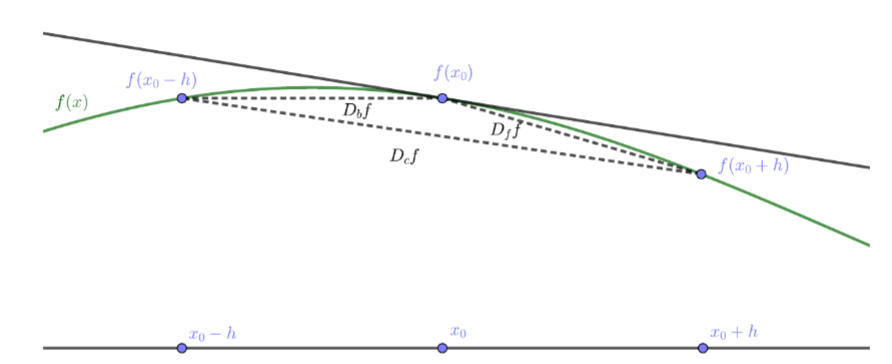

**Diferenciación Forward:** Diferencia Progresiva. Pendiente Secante entre x y x + h 

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h} + O(h)$$

**Diferenciación Backward:** Diferencia Regresiva. Pendiente Secante entre x - h y x 

$$f'(x) = \lim_{h \to 0} \frac{f(x) - f(x-h)}{h} + O(h)$$

**Diferenciación Centrada:** Diferencia Regresiva. Pendiente Secante entre x - h y x + h 

$$f'(x) = \lim_{h \to 0} \frac{f(x + h) - f(x-h)}{2h} + O(h^2)$$

In [24]:
def calc_fd(f,x,h):
    return (f(x + h)- f(x))/(h)

def calc_bd(f,x,h):
    return (f(x)- f(x - h))/(h)

def calc_cd(f,x,h):
    return (f(x+h) - f(x-h))/(2*h)

### _Analisis del Error_

**$\epsilon_r$**: Error de Redondeo introducido por las limitaciones de la aritmetica del ordenador al representar reales  
**$\epsilon_d$**: Error de Discretización. Ocurre al reemplazar un problema continuo por una aproximación discreta que el ordenador puede resolver

**Problemas con los valores de h:** Cuando h es muy pequeño, ocurre cancelación catastrofica. Existe una h optima

In [25]:
f = lambda x: np.exp(np.sin(2*x))
df = lambda x: 2*np.cos(2*x)*np.exp(np.sin(2*x))

x = 0.5
true_val = df(x)

h_vals = [10**-n for n in range(1,16)]
errs_fd = []
errs_bd = []
errs_cd = []

In [26]:
for h in h_vals:

    fd = calc_fd(f,x,h)
    bd = calc_bd(f,x,h)
    cd = calc_cd(f,x,h)

    err_fd = np.abs(fd - true_val)
    err_bd = np.abs(bd - true_val)
    err_cd = np.abs(cd - true_val)

    errs_fd.append(err_fd)
    errs_bd.append(err_bd)
    errs_cd.append(err_cd)

    print(f"h = {h}")
    print(f"fd = {fd}, Error: {err_fd}")

    print(f"bd = {bd}, Error: {err_bd}")
    print(f"cd = {cd}, Error: {err_cd}")

h = 0.1
fd = 2.199057076649269, Error: 0.30770445833762494
bd = 2.707681745515784, Error: 0.2009202105288903
cd = 2.4533694110825266, Error: 0.05339212390436732
h = 0.01
fd = 2.4807256192968197, Error: 0.02603591569007424
bd = 2.5317171676925376, Error: 0.024955632705643715
cd = 2.5062213934946787, Error: 0.0005401414922152625
h = 0.001
fd = 2.5042064928371133, Error: 0.0025550421497806397
bd = 2.509305773052528, Error: 0.0025442380656341967
cd = 2.5067561329448207, Error: 5.40204207322148e-06
h = 0.0001
fd = 2.5065065168927703, Error: 0.00025501809412364906
bd = 2.507016445036925, Error: 0.0002549100500308654
cd = 2.5067614809648475, Error: 5.402204639182173e-08
h = 1e-05
fd = 2.506736038032642, Error: 2.549695425191345e-05
bd = 2.5067870308426166, Error: 2.54958557226459e-05
cd = 2.5067615344376293, Error: 5.492646337756923e-10
h = 1e-06
fd = 2.506758985720836, Error: 2.549266057805255e-06
bd = 2.5067640843090544, Error: 2.549322160483314e-06
cd = 2.5067615350149453, Error: 2.8051339

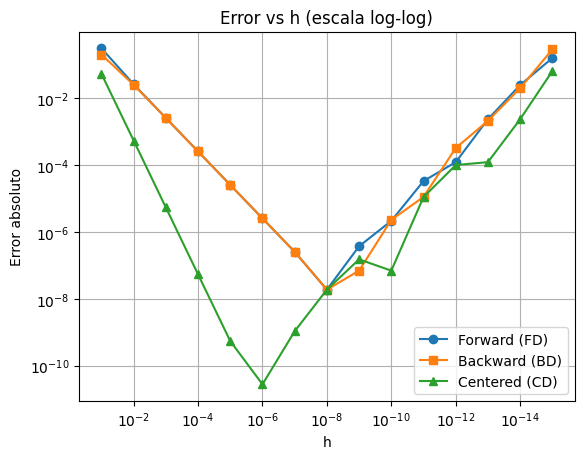

In [27]:
plt.figure()

plt.loglog(h_vals, errs_fd, 'o-', label='Forward (FD)')
plt.loglog(h_vals, errs_bd, 's-', label='Backward (BD)')
plt.loglog(h_vals, errs_cd, '^-', label='Centered (CD)')

plt.xlabel('h')
plt.ylabel('Error absoluto')
plt.title('Error vs h (escala log-log)')
plt.legend()
plt.grid(True, which="both")

plt.gca().invert_xaxis()

plt.show()

**h grande:** Domina el error de discretización  
**h pequeño:** Domina el error de redondeo  
**Minimo:** h optimo  

**Forward:**
- $h_{opt} \approx 3·10^{-8}$
- $\epsilon_{opt} \approx 3 · 10^{-8}$  

**Centrada:**
- $h_{opt} \approx 3·10^{-5}$
- $\epsilon_{opt} \approx 3 · 10^{-11}$  

### _Derivadas de Orden Superior_

**Idea:** Sumar los desarrollos de Taylor  para eliminar derivadas impares

$$f''(x) = \frac{f(x+h) - 2f(x) + f(x-h)}{h^2}$$

### _Extrapolación de Richardson_

$G = \frac{2^p g(h/2) - g(h)}{2^p - 1} + O(h^{p+q})$

No hay cancelación cancelación catastrofica

**Forward:** $R_f(h) = 2D_f(h/2) - D_f(h)$ con p = 1 $\rightarrow R_f(h) = \frac{4f(x + \frac{h}{2}) - f(x+h) - 3f(x)}{h} + O(h^2)$  

**Centrada:** con p=2 $R_c(h) = \frac{4D_c(h/2) - D_c(h)}{3} + O(h^4)$

Richardson no nos dice cual es el nuevo orden

Permite reutilizar codigo ya implementado

### _Puntos de Malla_

Muchas veces no controlamos f: Solo tenemos valores de ($x_i,f(x_i)$) en una malla equiespaciada en [a,b]

$x_i = a + ih$

$h = \frac{b - a}{n - 1}$

**Para puntos interiores:** Usar derivada centrada

**Para puntos extremos:**
- Si $x_0$: Usamos forward
- Si $x_{n-1}$: Usamos backward

## <center>**4.2 - Ecuaciones Diferenciales Ordinarias**</center>

### _Problema del Valor Inicial_

**PVI:** $\frac{d}{dt}y(t) = f(t,y(t))$   $a \leq t \leq b$   $y(a) = 0$
- $y_0$: Estado inicial

**Forma Integral de EDO:** $ y(t) = y_0 + \int_{a}^{t} f(s,y(s))ds$

Un PVI requiere existencia y unicidad de la solución

**Condicion Estandar:** f es continua y Lipschitziana en y
- Existe un $L \geq 0$ tal que $|f(t,y_1) - f(t,y_2)| \leq L|y_1 - y_2|$

**Condición Suficiente**: Si f tiene derivada parcial acotada $|\frac{\partial f}{\partial y}| \leq M$ es Lipschitz con L = M

**Discretización del Intervalo:** Construimos una malla uniforme

### _Metodo de Euler Explicito_

Usamos diferenciación *forward*:

$$
y_{i+1} = y_i + h\,f(t_i,y_i)
$$

con

$$
y(0) = a.
$$

In [28]:
def euler_explicito(t,f,y0):
    n = len(t)
    
    y = np.zeros(n)
    y[0] = y0
    
    h = (t[-1] - t[0]) / (n-1)
    
    for i in range(n-1):
        y[i+1] = y[i] + h*f(t[i],y[i])
        
    return y

In [29]:
y0 = 1
h = 0.5
t = [n/2 for n in range(5)]

f = lambda t,y: y

y = euler_explicito(t,f,y0)

print("t = ", t)
print("y = ", y)

t =  [0.0, 0.5, 1.0, 1.5, 2.0]
y =  [1.     1.5    2.25   3.375  5.0625]


**Interpretación Geometrica:**
- Al inicio , esta sobre la solución exacta
- A partir del segundo paso, partimos de $(t_i,y_i)$ con $y_i \neq y(t_i)$
- El error crece con t

### _Analisis del Error_

**Error local de Truncamiento:** Error cometido en un unico paso suponiendo que se parte del valor exacto  
**Error global:** Error acumulado tras cada paso
El error global es de un orden inferior al local

**Para Euler Explicito**
- El error local es $O(h^2)$
- El error global es $O(h)$

El metodo de euler explicito es util por simplicidad, pero su convergencia es poco eficiente. Reducir el error a la mitad implica el doble de pasos

**Estrategias Para Mejorar el Orden:**
- **Euler Mejorado:** Método explícito de orden $O(h^2)$
- **Runge-Kutta**: Familias más generales de métodos de orden superior
- **Paso Adaptativo:** Ajuste dinamico del paso segun la estimación del error

### _Euler Implicito_

Aproximación mediante la diferenciación backward

$$
y_{i+1} = y_i + h\,f(t_{i+1},y_{i+1})
$$

Si la ecuación no es lineal, no se puede resolver de forma cerrada
- En cada paso es necesario resolver una ecuación no lineal:
  - Se trata de una ecuacion de punto fijo $y_{i+1} = F(y_{i+1})$ con $F(z) = y_i + hf(t_{i+1},z)$
- Cada paso tiene mayor coste que el de euler explicito a cambia de mayor estabilidad

**Para Euler Implicito**
- El error local es $O(h^2)$
- El error global es $O(h)$

### _Euler Mejorado (Heun)_

1. Realizar una predicción de $y_{i+1}$ con Euler. Esto es la pendiente en $t_i$
2. Utilizar la predicción para estimar la pendiente en $t_{i+1}$
3. Promediar para obtener el paso definitivo

**Fase Predictora:** Aplicación del euler explicito  
**Fase Correctora:** Media de pendientes

$$

y_{i+1} = y_i + \frac{h}{2}[f(t_i,y_i) + f(t_{i+1}, \tilde{y}_{i+1})]

$$

con

$$

\tilde{y}_{i+1} = y_i + hf(t_i, y_i)


$$

**Para Heun**
- El error local es $O(h^3)$
- El error global es $O(h^2)$

**Como Metodo de Runge-Kutta:**

$k_1 = f(t_i,y_i)$

$k_2 = f(t_i + h, y_i + hk_1)$

$y_{i+1} = y_i + h(\frac{1}{2}k_1 + \frac{1}{2}k_2)$

In [30]:
def heun(t, f, y0):
    n = len(t)
    y = np.zeros(n)
    h = (t[-1] - t[0]) / (n - 1)
    y[0] = y0
    for i in range(n - 1):
        k1 = f(t[i], y[i])
        k2 = f(t[i] + h, y[i] + h * k1)
        y[i+1] = y[i] + 0.5 * h * (k1 + k2)
    return y

## <center>**4.3 - Diferenciación Automatica**</center>